In [1]:
!pip install numpy pandas matplotlib opencv-python tensorflow keras scikit-learn mtcnn streamlit

In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [4]:
train_dir = "Dataset/Train"
val_dir = "Dataset/Validation"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.


In [6]:
print(train_data.class_indices)

{'Fake': 0, 'Real': 1}


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

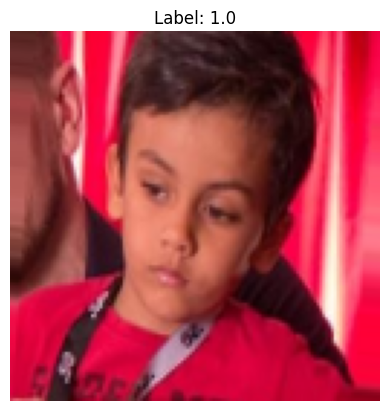

In [7]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.imshow(images[0]) // Display First Img
plt.title("Label: " + str(labels[0])) // Show Img Label
plt.axis('off')

In [8]:
import os
print(os.getcwd())
print(os.listdir())

/Users/Shubhamw/Deep Fake Project
['deepfake_model.h5', 'Untitled.ipynb', 'Dataset', '.ipynb_checkpoints']


In [9]:
import os
print(os.listdir())

['deepfake_model.h5', 'Untitled.ipynb', 'Dataset', '.ipynb_checkpoints']


In [10]:
train_dir = "Dataset/Train"
val_dir = "Dataset/Validation"

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # ⭐ MUST HAVE
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # single output
])

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [12]:
target_size=(128, 128)
batch_size=16


In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    steps_per_epoch=500,
    validation_steps=100
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.7244 - loss: 0.5415 - val_accuracy: 0.7906 - val_loss: 0.4573
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.7995 - loss: 0.4282 - val_accuracy: 0.8144 - val_loss: 0.4202
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.8183 - loss: 0.4014 - val_accuracy: 0.8012 - val_loss: 0.4710
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.8288 - loss: 0.3855 - val_accuracy: 0.7975 - val_loss: 0.4257
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.8329 - loss: 0.3623 - val_accuracy: 0.8325 - val_loss: 0.4013


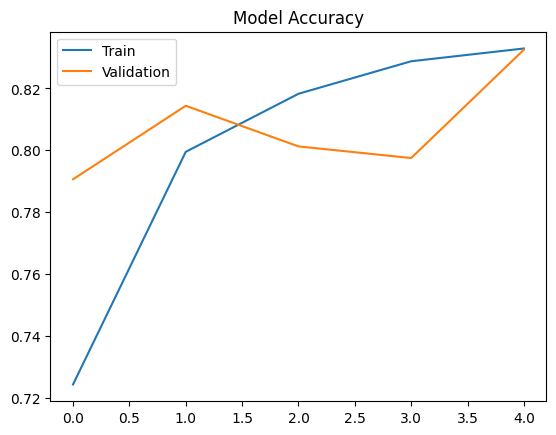

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("deepfake_model.h5")

def predict_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    img = img.reshape(1, 128, 128, 3)
    
    pred = model.predict(img)[0][0]
    
    if pred > 0.5:
        print("Real ✅")
    else:
        print("Fake ❌")

In [18]:
predict_image("test.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
Real ✅
